# 06. BL Q 추정 방식 비교

동일한 BL Baseline 구조에서 **Q(뷰 수익률) 추정 방식만 다르게** 설정하여 성과를 비교한다.

## 비교 대상
| 방식 | 공식 | 특징 |
|------|------|------|
| **Q_FIXED** | 05번 Baseline 최적값 자동 로드 | 05_Q_Sensitivity에서 Sharpe 최대 기준 선택 |
| **Q_hist** | mean(저위험 - 고위험) over 60M | 학습 기간 전체 평균 실현수익 |
| **Q_ff3** | FF3 회귀 추정 기대수익 | 팩터 모델 기반 예측 |
| **Q_momentum** | mean(저위험 - 고위험) over 최근 12M | 단기 추세 — Q_hist와 같은 공식, 짧은 window |
| **Q_lambda** | Q_FIXED × (λ_t / λ_mean) | 위험회피계수로 Q 강도 조정 |

> **Q_hist vs Q_momentum**: 공식은 동일(`저위험 수익 - 고위험 수익`), window만 다름.
> Q_hist(60M)는 장기 평균이라 거의 항상 양수. Q_momentum(12M)는 최근 추세를 따라 음수로도 뒤집힘.
>
> **Q_lambda**: (저위험 - 고위험) 스프레드가 아닌 **시장 위험회피 강도**를 신호로 사용.
> λ가 높으면(risk-off) 저위험 선호가 강해지므로 Q를 키우고, 낮으면(risk-on) 줄임.

## 실행 의존성
```
05_Q_Sensitivity → q_sensitivity_baseline_stats.csv (Q_FIXED 자동 로드)
```

## 벤치마크
- **CAPM 균형**: BL 없이 μ=π 그대로 최적화
- **S&P 500 (SPY)**: 시장 지수

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import io, re, zipfile, requests
import warnings
import platform
from pathlib import Path
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize

warnings.filterwarnings('ignore')
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False

BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / 'data'
OUT_DIR  = BASE_DIR / 'outputs' / '06_BL_Q_Comparison'
OUT_DIR.mkdir(parents=True, exist_ok=True)

# ── 파라미터 ────────────────────────────────────────────────
TRAIN_WINDOW     = 60
TAU              = 0.1
PCT_GROUP        = 0.30
START_PRED       = '2011-01-01'  # GARCH 시작 시점에 맞춰 통일 (07~08과 동일)
MOMENTUM_WINDOW  = 12            # Q_momentum: 최근 12개월 P 팩터 수익 평균
LAM_MEAN         = 2.5           # Q_lambda: 위험회피계수 장기 평균 (BL 문헌 기본값)

# ── Baseline 최적 Q 로드 (05_Q_Sensitivity 결과) ─────────────
BL_STATS = BASE_DIR / 'outputs' / '05_Q_Sensitivity' / 'q_sensitivity_baseline_stats.csv'
if BL_STATS.exists():
    _bs = pd.read_csv(BL_STATS, index_col='label')
    Q_FIXED = float(_bs['sharpe'].idxmax().split('=')[1])
    print(f'05번 Baseline 최적 Q 로드 → Q_FIXED = {Q_FIXED}')
else:
    Q_FIXED = 0.003  # 05 미실행 시 기본값
    print(f'05번 결과 없음 → 기본값 사용: Q_FIXED = {Q_FIXED}')
    print('  (05_Q_Sensitivity.ipynb 먼저 실행하면 최적값이 자동 적용됩니다)')

# ── 데이터 로드 ──────────────────────────────────────────────
panel = pd.read_csv(DATA_DIR / 'monthly_panel.csv', parse_dates=['date'])
panel = panel.set_index(['date', 'ticker'])

all_dates  = panel.index.get_level_values('date').unique().sort_values()
pred_dates = all_dates[all_dates >= START_PRED]

print(f'패널: {panel.shape}')
print(f'예측 기간: {pred_dates[0].date()} ~ {pred_dates[-1].date()} ({len(pred_dates)}개월)')
print(f'Q_FIXED = {Q_FIXED}  (월 {Q_FIXED*100:.1f}%  |  연 {Q_FIXED*12*100:.1f}%)')
print(f'MOMENTUM_WINDOW = {MOMENTUM_WINDOW}개월  |  LAM_MEAN = {LAM_MEAN}')

In [7]:
# ── FF3 팩터 로드 ─────────────────────────────────────────────
FF3_PATH = DATA_DIR / 'ff3_monthly.csv'

def download_ff3():
    url = ('https://mba.tuck.dartmouth.edu/pages/faculty/ken.french/ftp/'
           'F-F_Research_Data_Factors_CSV.zip')
    resp = requests.get(url, timeout=60)
    with zipfile.ZipFile(io.BytesIO(resp.content)) as zf:
        raw = zf.read(zf.namelist()[0]).decode('utf-8', errors='ignore')
    lines = raw.splitlines()
    start = next(i for i, l in enumerate(lines) if re.match(r'^\s*\d{6}\s*,', l))
    end   = next((i for i in range(start, len(lines))
                  if not re.match(r'^\s*\d{6}\s*,', lines[i])), len(lines))
    df = pd.read_csv(io.StringIO('\n'.join(lines[start-1:end])))
    df.columns = [c.strip() for c in df.columns]
    date_col = df.columns[0]
    df[date_col] = pd.to_datetime(df[date_col].astype(str), format='%Y%m') + pd.offsets.MonthEnd(0)
    df = df.rename(columns={date_col: 'date', 'Mkt-RF': 'mkt_rf',
                             'SMB': 'smb', 'HML': 'hml', 'RF': 'rf'})
    return df.set_index('date').astype(float) / 100.0

if FF3_PATH.exists():
    ff3 = pd.read_csv(FF3_PATH, index_col='date', parse_dates=True)
    print(f'FF3 로드: {ff3.shape}')
else:
    print('FF3 다운로드 중...')
    ff3 = download_ff3()
    ff3.to_csv(FF3_PATH)
    print(f'FF3 저장: {ff3.shape}')

print(ff3.tail(3))

FF3 로드: (1196, 4)
            mkt_rf     smb     hml      rf
date                                      
2025-12-31 -0.0036 -0.0106  0.0242  0.0034
2026-01-31  0.0102  0.0220  0.0372  0.0030
2026-02-28 -0.0117  0.0014  0.0283  0.0028


In [8]:
# ── BL 구성 함수 ──────────────────────────────────────────────

def compute_sigma(ret_matrix):
    lw = LedoitWolf().fit(ret_matrix.values)
    return pd.DataFrame(lw.covariance_,
                        index=ret_matrix.columns,
                        columns=ret_matrix.columns)


def compute_pi(Sigma, w_mkt, spy_excess_ret, sigma2_mkt):
    lam = spy_excess_ret / sigma2_mkt if sigma2_mkt > 0 else 2.5
    lam = np.clip(lam, 0.5, 10.0)
    return lam * Sigma @ w_mkt, lam


def build_P(vol_series, mcap_series, pct=0.30):
    n_group    = max(1, int(len(vol_series) * pct))
    sorted_idx = vol_series.sort_values().index
    low_risk   = sorted_idx[:n_group]
    high_risk  = sorted_idx[-n_group:]
    P = pd.Series(0.0, index=vol_series.index)
    low_m  = mcap_series[low_risk]
    high_m = mcap_series[high_risk]
    P[low_risk]  =  low_m  / low_m.sum()
    P[high_risk] = -high_m / high_m.sum()
    return P


def compute_Q_hist(P, ret_matrix):
    """Q = 학습 기간(60M) 전체 P 포트폴리오 평균 실현수익률
    공식: mean(저위험 수익 - 고위험 수익) over TRAIN_WINDOW"""
    p_vec = P.reindex(ret_matrix.columns).fillna(0).values
    return float((ret_matrix.values @ p_vec).mean())


def compute_Q_momentum(P, ret_matrix, window=12):
    """Q = 최근 window개월 P 포트폴리오 평균 실현수익률 (단기 모멘텀 신호)
    공식: mean(저위험 수익 - 고위험 수익) over 최근 window개월

    Q_hist와 동일한 (저위험 - 고위험) 공식이지만 window가 짧아 최근 추세를 포착.
    최근 저위험이 고위험을 이기면 양수(모멘텀 지속 기대),
    최근 역전됐으면 음수(BL이 고위험 쪽으로 tilt)."""
    n = min(window, len(ret_matrix))
    if n < 3:
        return compute_Q_hist(P, ret_matrix)
    p_vec  = P.reindex(ret_matrix.columns).fillna(0).values
    recent = ret_matrix.iloc[-n:]
    return float((recent.values @ p_vec).mean())


def compute_Q_lambda(lam, q_base, lam_mean=2.5):
    """Q = q_base × (λ_t / λ_mean) — 위험회피계수로 Q 강도 조정

    λ_t = 이번 달 학습 기간에서 추정된 위험회피계수 (SPY 초과수익 / σ²_mkt)
    λ_mean = 장기 평균 위험회피계수 (기본값 2.5, BL 문헌 표준)

    λ 높음(risk-off): 시장이 저위험 자산을 강하게 선호 → Q 확대 → BL tilt 강화
    λ 낮음(risk-on) : 고수익 위험 자산 선호 → 저위험 프리미엄 약화 → Q 축소
    scale을 [0.1, 3.0]으로 제한하여 극단적 Q 발생 방지."""
    scale = np.clip(lam / lam_mean, 0.1, 3.0)
    return float(q_base * scale)


def compute_Q_ff3(P, ret_matrix, ff3_train, rf_train):
    """Q = FF3 회귀로 추정한 P 포트폴리오 기대수익률"""
    view_tickers = [t for t in P[P != 0].index if t in ret_matrix.columns]
    if not view_tickers:
        return 0.0
    ff3_aligned = ff3_train.reindex(ret_matrix.index).dropna()
    rf_aligned  = rf_train.reindex(ff3_aligned.index).fillna(0)
    n = len(ff3_aligned)
    if n < 24:
        return 0.0
    X      = np.column_stack([np.ones(n), ff3_aligned[['mkt_rf', 'smb', 'hml']].values])
    X_next = np.array([1.0] + ff3_aligned[['mkt_rf', 'smb', 'hml']].tail(12).mean().tolist())
    rf_next = float(rf_train.iloc[-1]) if len(rf_train) > 0 else 0.0
    Y    = (ret_matrix[view_tickers].reindex(ff3_aligned.index).fillna(0).values
            - rf_aligned.values.reshape(-1, 1))
    coef = np.linalg.lstsq(X, Y, rcond=None)[0]
    r_hat_view = X_next @ coef + rf_next
    r_hat = pd.Series(0.0, index=ret_matrix.columns)
    for j, t in enumerate(view_tickers):
        r_hat[t] = r_hat_view[j]
    return float(P.reindex(ret_matrix.columns).fillna(0) @ r_hat)


def compute_omega(P, Sigma, tau):
    p = P.values
    return max(float(tau * p @ Sigma.values @ p), 1e-8)


def black_litterman(pi, Sigma, P, q, omega, tau):
    p    = P.values
    pi_v = pi.values
    tSig = tau * Sigma.values
    M      = float(p @ tSig @ p) + omega
    diff   = q - float(p @ pi_v)
    adjust = tSig @ p * (diff / M)
    return pd.Series(pi_v + adjust, index=pi.index)


def optimize_portfolio(mu, Sigma, lam):
    n   = len(mu)
    mu_ = mu.values
    Sig = Sigma.values
    def obj(w): return 0.5 * lam * w @ Sig @ w - w @ mu_
    def jac(w): return lam * Sig @ w - mu_
    res = minimize(obj, np.ones(n)/n, jac=jac, method='SLSQP',
                   bounds=[(0, 1)]*n,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum()-1}])
    if not res.success:
        import warnings
        warnings.warn(f'optimize_portfolio 수렴 실패 → 1/N 대체: {res.message}')
    w = res.x if res.success else np.ones(n)/n
    return pd.Series(w, index=mu.index)


print('BL 함수 정의 완료')
print('Q 추정 함수: Q_hist | Q_momentum | Q_lambda | Q_ff3')


BL 함수 정의 완료
Q 추정 함수: Q_hist | Q_momentum | Q_lambda | Q_ff3


In [9]:
# ── Walk-forward: Q 방식별 결과 수집 ──────────────────────────
ret_pivot  = panel['ret_1m'].unstack('ticker')
spy_series = panel['spy_ret'].groupby(level='date').first()
rf_series  = panel['rf_1m'].groupby(level='date').first()
# 결과 저장소
results = {
    'Q_FIXED':    [],
    'Q_hist':     [],
    'Q_momentum': [],
    'Q_lambda':   [],
    'Q_ff3':      [],
    'CAPM':       [],
    'SPY':        [],
}
q_log = []
print(f'Walk-forward: {pred_dates[0].date()} ~ {pred_dates[-1].date()}')
for i, pred_date in enumerate(pred_dates):
    if (i + 1) % 12 == 0:
        print(f'  {pred_date.date()} ({i+1}/{len(pred_dates)})')
    try:
        month_df = panel.xs(pred_date, level='date').dropna(
            subset=['vol_21d', 'log_mcap', 'ret_1m'])
        if len(month_df) < 30:
            continue
        universe = month_df.index.tolist()
        idx         = all_dates.get_loc(pred_date)
        train_dates = all_dates[max(0, idx - TRAIN_WINDOW): idx]
        thresh    = int(len(train_dates) * 0.7)
        ret_slice = (ret_pivot.reindex(index=train_dates, columns=universe)
                              .dropna(axis=1, thresh=thresh)
                              .fillna(0))
        valid_tix = ret_slice.columns.tolist()
        if len(valid_tix) < 20:
            continue
        month_df = month_df.reindex(valid_tix)
        Sigma    = compute_sigma(ret_slice)
        mcap  = np.exp(month_df['log_mcap'])
        w_mkt = (mcap / mcap.sum()).reindex(valid_tix).fillna(0)
        spy_s      = spy_series.reindex(train_dates)
        rf_s       = rf_series.reindex(train_dates)
        spy_excess = (spy_s - rf_s).mean()
        sigma2_mkt = spy_s.var()
        pi, lam = compute_pi(Sigma, w_mkt, spy_excess, sigma2_mkt)
        P = build_P(month_df['vol_21d'], mcap, pct=PCT_GROUP)
        P = P.reindex(valid_tix).fillna(0)
        omega = compute_omega(P, Sigma, TAU)
        # ── Q 방식별 계산 ────────────────────────────────────
        q_fixed    = Q_FIXED
        q_hist     = compute_Q_hist(P, ret_slice)
        q_momentum = compute_Q_momentum(P, ret_slice, window=MOMENTUM_WINDOW)
        q_lambda   = compute_Q_lambda(lam, Q_FIXED, lam_mean=LAM_MEAN)
        q_ff3      = compute_Q_ff3(P, ret_slice, ff3.reindex(train_dates), rf_s)
        q_log.append({'date':       pred_date,
                      'Q_FIXED':    q_fixed,
                      'Q_hist':     q_hist,
                      'Q_momentum': q_momentum,
                      'Q_lambda':   q_lambda,
                      'Q_ff3':      q_ff3,
                      'lam':        lam})
        # ── Q별 BL → 포트폴리오 가중치 ──────────────────────
        next_date  = all_dates[idx + 1] if idx + 1 < len(all_dates) else None
        actual_ret = (ret_pivot.loc[next_date].reindex(valid_tix).fillna(0)
                            if next_date is not None
                            else month_df['fwd_ret_1m'].reindex(valid_tix).fillna(0))
        r_spy      = float(spy_series.get(next_date, np.nan)) if next_date else np.nan
        for q_name, q_val in [('Q_FIXED',    q_fixed),
                               ('Q_hist',     q_hist),
                               ('Q_momentum', q_momentum),
                               ('Q_lambda',   q_lambda),
                               ('Q_ff3',      q_ff3)]:
            mu_BL = black_litterman(pi, Sigma, P, q_val, omega, TAU)
            w_bl  = optimize_portfolio(mu_BL, Sigma, lam)
            results[q_name].append({'date': pred_date, 'ret': float(w_bl @ actual_ret)})
        w_capm = optimize_portfolio(pi, Sigma, lam)
        results['CAPM'].append({'date': pred_date, 'ret': float(w_capm @ actual_ret)})
        results['SPY'].append({'date': pred_date, 'ret': r_spy})
    except Exception as e:
        if len(results['Q_FIXED']) <= 3:
            print(f'  [에러] {pred_date.date()}: {e}')
# DataFrame 변환
ret_series = {k: pd.DataFrame(v).set_index('date')['ret']
              for k, v in results.items()}
q_df = pd.DataFrame(q_log).set_index('date')
print(f'\n완료: {len(ret_series["Q_FIXED"])}개월')


Walk-forward: 2011-01-31 ~ 2025-12-31
  2011-12-31 (12/180)
  2012-12-31 (24/180)
  2013-12-31 (36/180)
  2014-12-31 (48/180)
  2015-12-31 (60/180)
  2016-12-31 (72/180)
  2017-12-31 (84/180)
  2018-12-31 (96/180)
  2019-12-31 (108/180)
  2020-12-31 (120/180)
  2021-12-31 (132/180)
  2022-12-31 (144/180)
  2023-12-31 (156/180)
  2024-12-31 (168/180)
  2025-12-31 (180/180)

완료: 180개월


=== 월별 Q 값 기술통계 ===
       Q_FIXED    Q_hist  Q_momentum  Q_lambda     Q_ff3
count  180.000  180.0000    180.0000  180.0000  180.0000
mean     0.003   -0.0025     -0.0014    0.0062   -0.0026
std      0.000    0.0057      0.0134    0.0030    0.0096
min      0.003   -0.0206     -0.0310    0.0006   -0.0273
25%      0.003   -0.0052     -0.0113    0.0039   -0.0079
50%      0.003   -0.0015     -0.0010    0.0074   -0.0025
75%      0.003    0.0011      0.0079    0.0090    0.0031
max      0.003    0.0139      0.0330    0.0090    0.0321


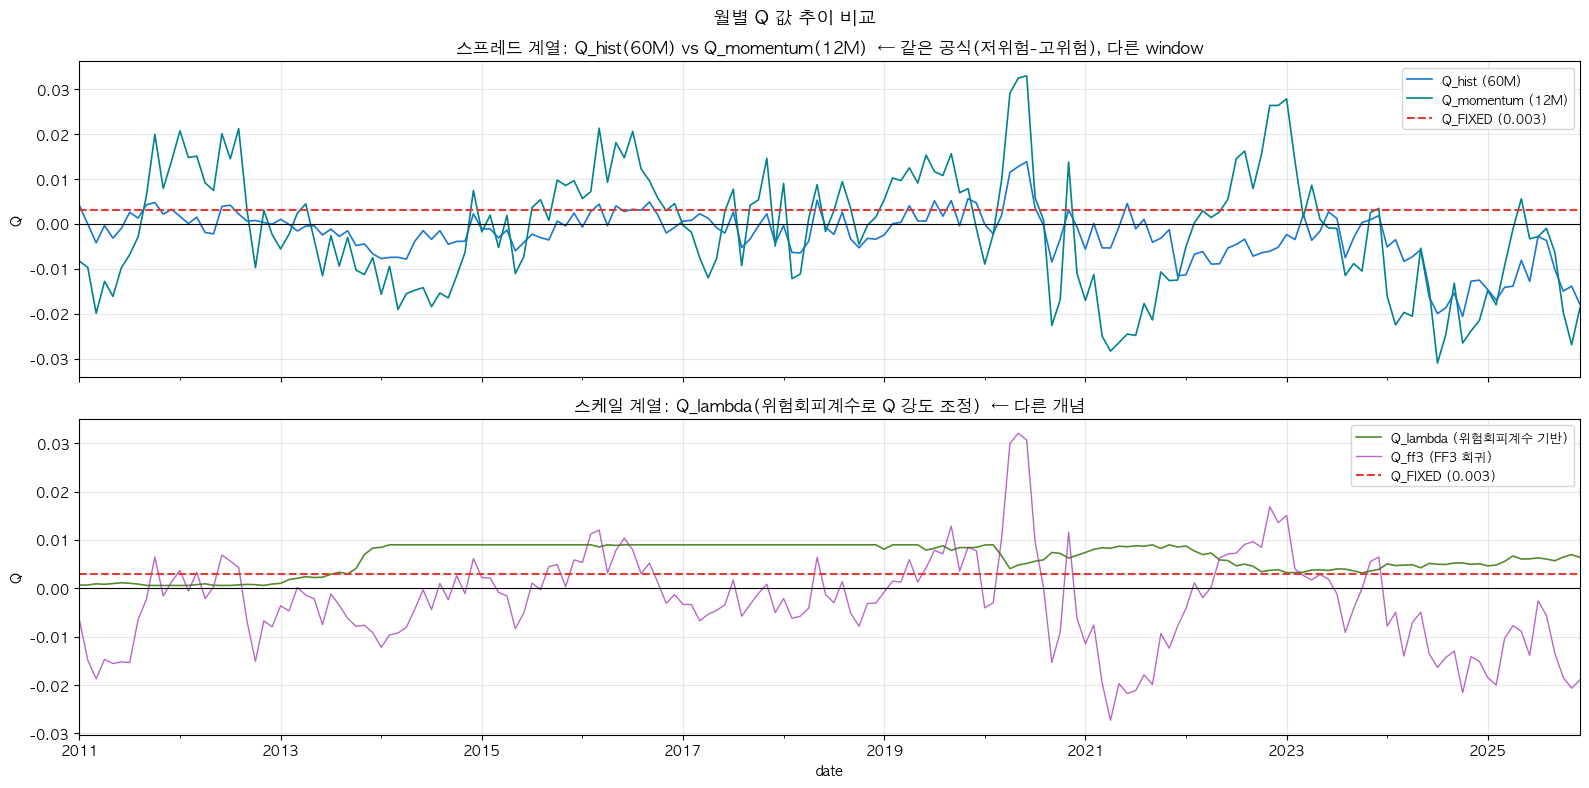


위험회피계수(λ) 통계:
  평균: 5.876  중앙값: 6.133
  min: 0.500  max: 10.000
  → Q_lambda 범위: 0.0006 ~ 0.0090


In [10]:
# ── Q 수준 비교 ───────────────────────────────────────────────
print('=== 월별 Q 값 기술통계 ===')
print(q_df[['Q_FIXED','Q_hist','Q_momentum','Q_lambda','Q_ff3']].describe().round(4))

fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=True)
fig.suptitle('월별 Q 값 추이 비교', fontsize=13, fontweight='bold')

# ① 스프레드 계열 (Q_hist, Q_momentum) — 같은 공식, 다른 window
ax = axes[0]
q_df['Q_hist'].plot(ax=ax, label=f'Q_hist (60M)', color='#1976D2', linewidth=1.2)
q_df['Q_momentum'].plot(ax=ax, label=f'Q_momentum ({MOMENTUM_WINDOW}M)', color='#00838F', linewidth=1.2)
ax.axhline(Q_FIXED, color='#E53935', linestyle='--', linewidth=1.5,
           label=f'Q_FIXED ({Q_FIXED:.3f})')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('스프레드 계열: Q_hist(60M) vs Q_momentum(12M)  ← 같은 공식(저위험-고위험), 다른 window')
ax.set_ylabel('Q')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

# ② 스케일 계열 (Q_lambda) + 참고용 Q_ff3
ax = axes[1]
q_df['Q_lambda'].plot(ax=ax, label='Q_lambda (위험회피계수 기반)', color='#558B2F', linewidth=1.2)
q_df['Q_ff3'].plot(ax=ax, label='Q_ff3 (FF3 회귀)', color='#9C27B0', linewidth=1.0, alpha=0.7)
ax.axhline(Q_FIXED, color='#E53935', linestyle='--', linewidth=1.5,
           label=f'Q_FIXED ({Q_FIXED:.3f})')
ax.axhline(0, color='black', linewidth=0.8)
ax.set_title('스케일 계열: Q_lambda(위험회피계수로 Q 강도 조정)  ← 다른 개념')
ax.set_ylabel('Q')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'q_values.png', dpi=150, bbox_inches='tight')
plt.show()

# λ 추이 확인
print(f'\n위험회피계수(λ) 통계:')
print(f'  평균: {q_df["lam"].mean():.3f}  중앙값: {q_df["lam"].median():.3f}')
print(f'  min: {q_df["lam"].min():.3f}  max: {q_df["lam"].max():.3f}')
print(f'  → Q_lambda 범위: {q_df["Q_lambda"].min():.4f} ~ {q_df["Q_lambda"].max():.4f}')

In [11]:
# ── 성과 분석 ────────────────────────────────────────────────
ANN = np.sqrt(12)
rf_monthly = panel['rf_1m'].groupby(level='date').first()

def performance(ret, label):
    rf      = rf_monthly.reindex(ret.index).fillna(0)
    excess  = ret - rf
    ann_ret = ret.mean() * 12
    ann_vol = ret.std() * ANN
    sharpe  = excess.mean() / excess.std() * ANN
    cum     = (1 + ret).cumprod()
    mdd     = ((cum - cum.cummax()) / cum.cummax()).min()
    cum_ret = cum.iloc[-1] - 1
    return {
        'label':    label,
        'ann_ret':  ann_ret,
        'ann_vol':  ann_vol,
        'sharpe':   sharpe,
        'cum_ret':  cum_ret,
        'mdd':      mdd,
    }

stats = [performance(ret_series[k], k)
         for k in ['Q_FIXED', 'Q_hist', 'Q_momentum', 'Q_lambda', 'Q_ff3', 'CAPM', 'SPY']]

stats_df = pd.DataFrame(stats).set_index('label')
stats_df[['ann_ret', 'ann_vol', 'sharpe', 'cum_ret', 'mdd']] = \
    stats_df[['ann_ret', 'ann_vol', 'sharpe', 'cum_ret', 'mdd']].round(4)

print('=== 포트폴리오 성과 비교 ===')
display_df = stats_df.copy()
display_df['ann_ret'] = display_df['ann_ret'].map('{:.2%}'.format)
display_df['ann_vol'] = display_df['ann_vol'].map('{:.2%}'.format)
display_df['sharpe']  = display_df['sharpe'].map('{:.3f}'.format)
display_df['cum_ret'] = display_df['cum_ret'].map('{:.2%}'.format)
display_df['mdd']     = display_df['mdd'].map('{:.2%}'.format)
display_df.columns   = ['연환산수익률', '연환산변동성', 'Sharpe', '누적수익률', 'MDD']
print(display_df.to_string())

# 신규 Q 방법과 Q_FIXED 대비 Sharpe 차이 출력
base = stats_df.loc['Q_FIXED', 'sharpe']
print()
print(f'vs Q_FIXED (Sharpe {base:.3f}):')
for name in ['Q_hist', 'Q_momentum', 'Q_lambda', 'Q_ff3', 'CAPM']:
    diff = stats_df.loc[name, 'sharpe'] - base
    print(f'  {name:15s}: {diff:+.3f}')

=== 포트폴리오 성과 비교 ===
            연환산수익률  연환산변동성 Sharpe    누적수익률      MDD
label                                              
Q_FIXED     13.77%  11.44%  1.074  608.29%  -13.70%
Q_hist      14.19%  14.24%  0.896  613.83%  -21.57%
Q_momentum  10.58%  15.33%  0.597  307.68%  -42.00%
Q_lambda    13.73%  11.01%  1.112  609.29%  -11.84%
Q_ff3       11.26%  16.79%  0.586  332.93%  -51.48%
CAPM        14.21%  14.49%  0.882  612.78%  -22.17%
SPY         14.03%  14.06%  0.898     nan%  -23.93%

vs Q_FIXED (Sharpe 1.074):
  Q_hist         : -0.178
  Q_momentum     : -0.477
  Q_lambda       : +0.038
  Q_ff3          : -0.489
  CAPM           : -0.193


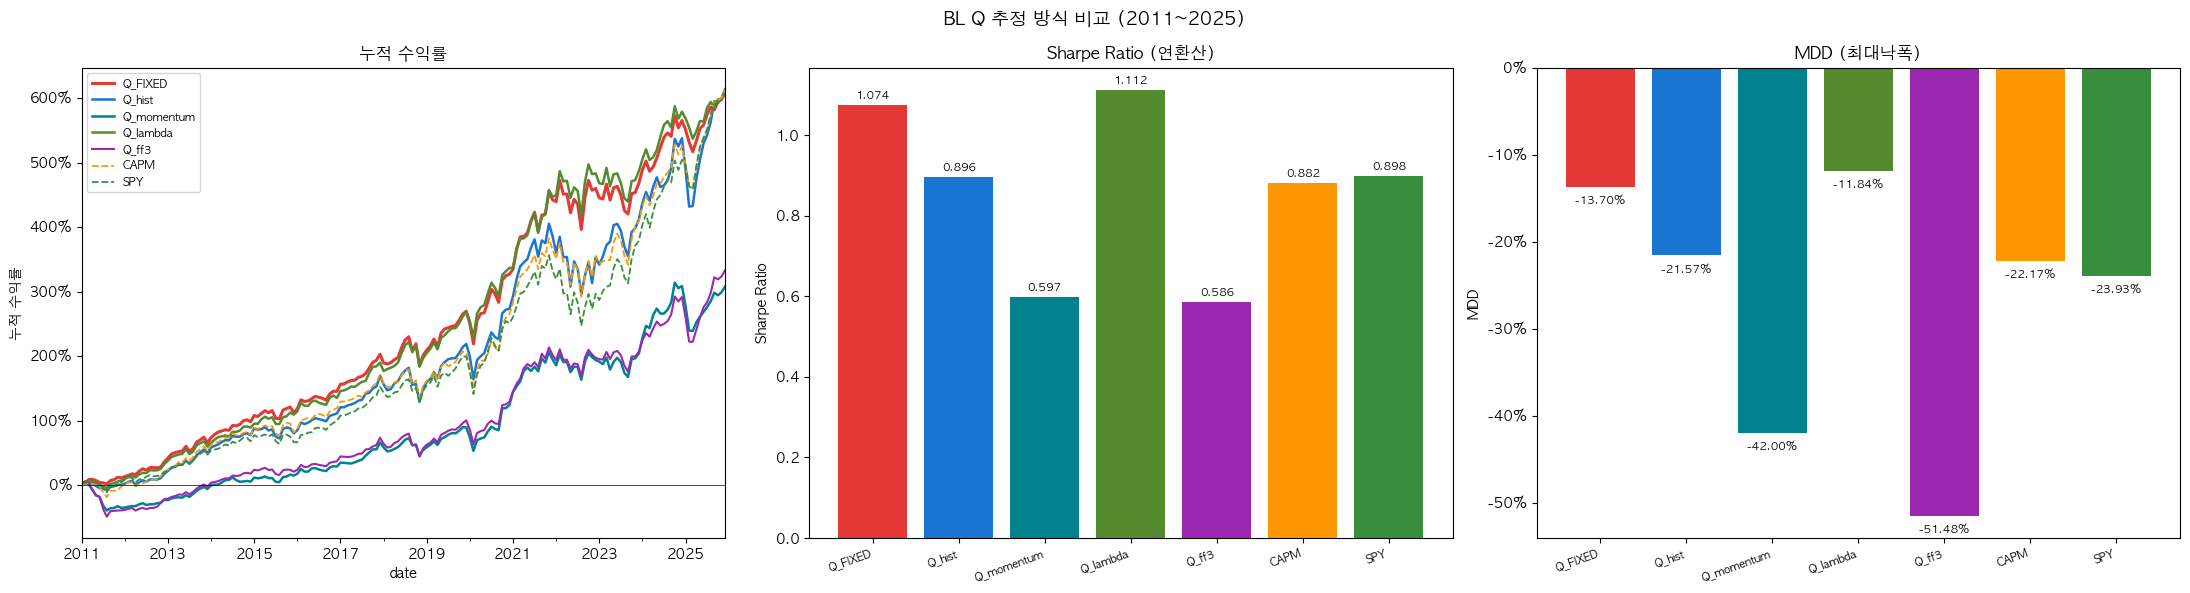

저장 완료


In [12]:
# ── 시각화 ───────────────────────────────────────────────────
palette = {
    'Q_FIXED':    ('#E53935', 2.2, '-'),
    'Q_hist':     ('#1976D2', 1.8, '-'),
    'Q_momentum': ('#00838F', 1.8, '-'),
    'Q_lambda':   ('#558B2F', 1.8, '-'),
    'Q_ff3':      ('#9C27B0', 1.5, '-'),
    'CAPM':       ('#FF9800', 1.3, '--'),
    'SPY':        ('#388E3C', 1.3, '--'),
}

fig, axes = plt.subplots(1, 3, figsize=(22, 6))
fig.suptitle('BL Q 추정 방식 비교 (2011~2025)', fontsize=13, fontweight='bold')

# ① 누적 수익률
ax = axes[0]
for name, (color, lw, ls) in palette.items():
    cum = (1 + ret_series[name]).cumprod() - 1
    cum.plot(ax=ax, label=name, color=color, linewidth=lw, linestyle=ls)
ax.set_title('누적 수익률')
ax.set_ylabel('누적 수익률')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(fontsize=8)
ax.axhline(0, color='black', linewidth=0.5)

# ② Sharpe Ratio
ax = axes[1]
names   = [s['label']  for s in stats]
sharpes = [s['sharpe'] for s in stats]
colors  = [palette[n][0] for n in names]
bars = ax.bar(names, sharpes, color=colors)
ax.set_title('Sharpe Ratio (연환산)')
ax.set_ylabel('Sharpe Ratio')
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
for bar, val in zip(bars, sharpes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{val:.3f}', ha='center', va='bottom', fontsize=8, fontweight='bold')

# ③ MDD
ax = axes[2]
mdds = [s['mdd'] for s in stats]
bars = ax.bar(names, mdds, color=colors)
ax.set_title('MDD (최대낙폭)')
ax.set_ylabel('MDD')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.axhline(0, color='black', linewidth=0.5)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=8)
for bar, val in zip(bars, mdds):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() - 0.01,
            f'{val:.2%}', ha='center', va='top', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.savefig(OUT_DIR / 'q_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# 결과 저장
result_df = pd.DataFrame(ret_series)
result_df.to_csv(DATA_DIR / 'q_comparison_returns.csv')
print('저장 완료')